## L10 - Pipelines

### Notebook code 

X.shape=(29, 1),  y.shape=(29,)
OK
The MLP may mis-fit the data, seen in the, sometimes, bad R^2 score..

lin.reg.score(X, y)=0.73
    MLP.score(X, y)=-13154.86

OK


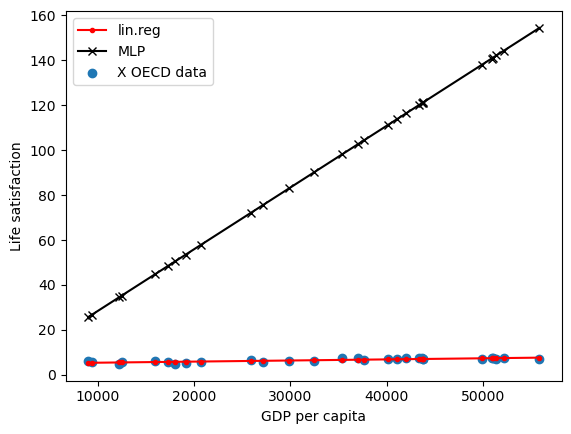

In [1]:
%matplotlib inline

import sys
import pickle
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def LoadDataFromL01():
    filename = "Data/itmal_l01_data.pkl"
    with open(f"{filename}", "rb") as f:
        (X, y) = pickle.load(f)
        return X, y

X, y = LoadDataFromL01()

print(f"X.shape={X.shape},  y.shape={y.shape}")

assert X.shape[0] == y.shape[0]
assert X.ndim == 2
assert y.ndim == 1  # did a y.ravel() before saving to picke file
assert X.shape[0] == 29

# re-create plot data (not stored in the Pickel file)
m = np.linspace(0, 60000, 1000)
M = np.empty([m.shape[0], 1])
M[:, 0] = m

print("OK")

# Setup the MLP and lin. regression again..

def isNumpyData(t: np.ndarray, expected_ndim: int):
    assert isinstance(expected_ndim, int), f"input parameter 'expected_ndim' is not an integer but a '{type(expected_ndim)}'"
    assert expected_ndim>=0, f"expected input parameter 'expected_ndim' to be >=0, got {expected_ndim}"
    if t is None:
        print("input parameter 't' is None", file=sys.stderr)
        return False
    if not isinstance(t, np.ndarray):
        print("excepted numpy.ndarray got type '{type(t)}'", file=sys.stderr)
        return False
    if not t.ndim==expected_ndim:
        print("expected ndim={expected_ndim} but found {t.ndim}", file=sys.stderr)
        return False
    return True

def PlotModels(model1, model2, X: np.ndarray, y: np.ndarray, name_model1: str, name_model2: str):
    
    # NOTE: local function is such a nifty feature of Python!
    def CalcPredAndScore(model, X: np.ndarray, y: np.ndarray,):
        assert isNumpyData(X, 2) and isNumpyData(y, 1) and X.shape[0]==y.shape[0]
        y_pred_model = model.predict(X)
        score_model = r2_score(y, y_pred_model) # call r2
        return y_pred_model, score_model    

    assert isinstance(name_model1, str) and isinstance(name_model2, str)

    y_pred_model1, score_model1 = CalcPredAndScore(model1, X, y)
    y_pred_model2, score_model2 = CalcPredAndScore(model2, X, y)

    plt.plot(X, y_pred_model1, "r.-")
    plt.plot(X, y_pred_model2, "kx-")
    plt.scatter(X, y)
    plt.xlabel("GDP per capita")
    plt.ylabel("Life satisfaction")
    plt.legend([name_model1, name_model2, "X OECD data"])

    l = max(len(name_model1), len(name_model2))
    
    print(f"{(name_model1).rjust(l)}.score(X, y)={score_model1:0.2f}")
    print(f"{(name_model2).rjust(l)}.score(X, y)={score_model2:0.2f}")

# lets make a linear and MLP regressor and redo the plots
mlp = MLPRegressor(hidden_layer_sizes=(10, ),
                   solver='adam',
                   activation='relu',
                   tol=1E-5,
                   max_iter=100000,
                   verbose=False)
linreg = LinearRegression()

mlp.fit(X, y)
linreg.fit(X, y)

print("The MLP may mis-fit the data, seen in the, sometimes, bad R^2 score..\n")
PlotModels(linreg, mlp, X, y, "lin.reg", "MLP")
print("\nOK")

### Qa - Minmax scaler

The score on scaled data: 0.711837032372477


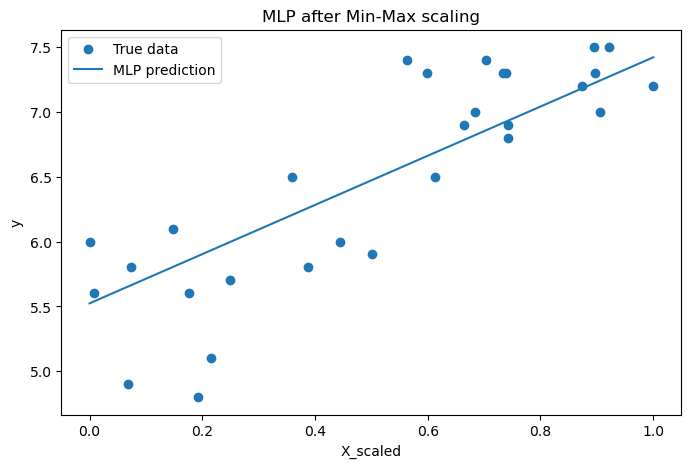

In [2]:
# TODO: add your code here..
# We will create a function the takes the dataset as input and scales the data using min max
import numpy as np

def MinMaxScaler(X):
    X = np.asarray(X)
    X_min = np.min(X,axis=0) # Taking the min of each column
    X_max = np.max(X,axis=0) # Taking the max of each column
    return (X - X_min) / (X_max - X_min)

# Scaling the data
X_scaled = MinMaxScaler(X)

# Retraining on scaled data
mlp.fit(X_scaled, y)
score = mlp.score(X_scaled, y)
print("The score on scaled data:",score)

y_pred = mlp.predict(X_scaled)

# Replotting
plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[:, 0], y, label="True data")
plt.plot(X_scaled[:, 0], y_pred, label="MLP prediction")
plt.xlabel("X_scaled")
plt.ylabel("y")
plt.title("MLP after Min-Max scaling")
plt.legend()
plt.show()

### Qb) Scikit-learn Pipelines

   lin.reg.score(X, y)=0.73
MLP+MinMax.score(X, y)=0.72


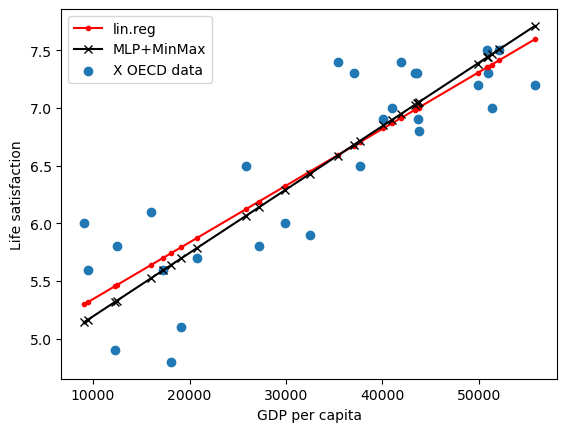

In [3]:
# TODO: add your code here..
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline

# Constructing pipelines
# Minmax pipeline
pipe = Pipeline([
    ('scaler', MinMaxScaler()),
    ('mlp', mlp)
])

lin_pipe = Pipeline([
    ('scaler', MinMaxScaler()),
    ('linreg', LinearRegression())
])

# fitting the data 
pipe.fit(X, y)
lin_pipe.fit(X, y)

PlotModels(lin_pipe, pipe, X, y, "lin.reg", "MLP+MinMax")

### Qc) Outliers and the Min-max Scaler vs. the Standard Scaler

The problem with the min-max scaler is that if the data has outliers that lie far away from the rest of the data, using the min-max scaler will crush the properties of the data as it has to scale the data so that the outlier also comes within the range of 0:1. To sum up all the important data would exist within a tiny interval near 0 and the outlier would be near 1.

As seen in the output below the standard scaler has a better score, but from the plotting its clear that the standard scaler is more sensitive to noise.

MLP+standard.score(X, y)=0.78
  MLP+MinMax.score(X, y)=0.72


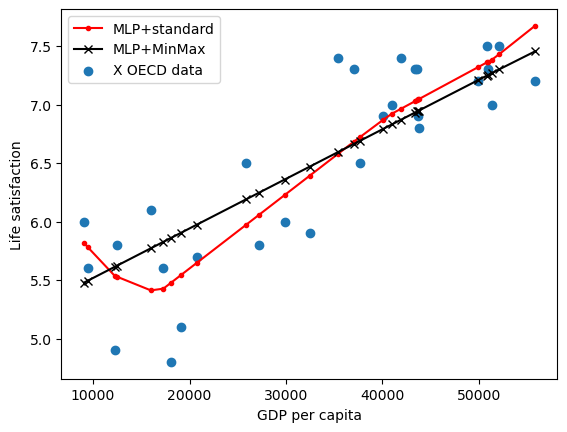

In [4]:
# TODO: research the problem here..
from sklearn.preprocessing import StandardScaler
# Constructing 
# Minmax regressor
mlp_minmax = MLPRegressor(hidden_layer_sizes=(10,),
                          solver='adam',
                          activation='relu',
                          tol=1E-5,
                          max_iter=100000,
                          verbose = False)
# Standard regressor
mlp_standard = MLPRegressor(hidden_layer_sizes=(10,),
                            solver='adam',
                            activation='relu',
                            tol=1E-5,
                            max_iter=100000,
                            verbose = False)

# constructing pipelines
pipe_minmax = Pipeline([
    ('scaler', MinMaxScaler()),
    ('mlp', mlp_minmax)
])

pipe_standard = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', mlp_standard)
])

pipe_minmax.fit(X, y) # Using min-max
pipe_standard.fit(X, y) # Using standard-scaler

PlotModels(pipe_standard, pipe_minmax, X, y, "MLP+standard", "MLP+MinMax")

### Qd) Modify the MLP Hyperparameters

The scores are generally bad as the data might be too small to use cross-validation. It can be concluded that 5-10 neurons should be enough for this dataset, the model performs much better with early stopping and the adam solver is the best.

In [5]:
# TODO: add your code here..
from sklearn.model_selection import cross_val_score

# Function that constructs a pipeline with the hyperparameters that are desired
def test_mlp(neurons=10, early=False, activation="relu", solver="adam"):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(
            hidden_layer_sizes=(neurons,),
            early_stopping=early,
            activation=activation,
            solver=solver,
            tol=1E-5,
            max_iter=20000,
            random_state=42
        ))
    ])
    
    scores = cross_val_score(pipe, X, y, cv=5, scoring="r2") # Using cross validation so the model evaluates on unseen data
    return scores.mean()

print("Scores with different neuron numbers")
for h in [1, 2, 3, 5, 8, 10, 15]:
    print(h, test_mlp(neurons=h))

# Trying early stopping
print("Early stopping with neurons=5")
print("No early stopping:", test_mlp(neurons=5, early=False))
print("With early stopping:", test_mlp(neurons=5, early=True))

# Trying different activations
for act in ["relu", "tanh", "logistic"]:
    print(act, test_mlp(neurons=5, activation=act))

# Trying different solvers
for solver in ["adam", "sgd", "lbfgs"]:
    print(solver, test_mlp(neurons=5, solver=solver))

Scores with different neuron numbers
1 -1.1071993302156735
2 -11.72137017150001
3 -4.604422124813985
5 -1.9255267297337089
8 -4.5130628276056575
10 -4.821201223228285
15 -2.7185339793401284
Early stopping with neurons=5
No early stopping: -1.9255267297337089
With early stopping: -20.951864012809377
relu -1.9255267297337089
tanh -0.7351779948333739
logistic -1.5135876941942328
adam -1.9255267297337089
sgd -28.194829037315536
lbfgs -3.559248316589733


### Conclusion

Across these exercises we found that scaling is essential when dealing with MLPs. Pipelines can be used to implement the preprossesing before fitting in a clean way. The 2 different scaling methods were implemented and it was found that minmax was sensitive to outliers, whereas the standard scaler was more sensitive to noise. Furthermore the different hyperparameters of the MLP were tested.

## L12 - MLP with Keras

### Notebook code

In [24]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
from time import strftime

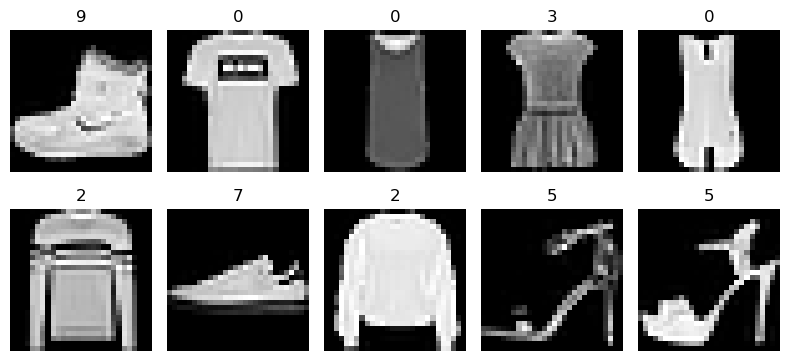

In [25]:
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

# Split training data into training and vvalidation sets - skiped since we are using validation_split

#X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
#y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

# Normalize pixel values to range [0, 1]
X_test = X_test / 255.0
X_train = X_train_full / 255.0
y_train = y_train_full

plt.figure(figsize=(8, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")
    plt.tight_layout()
plt.show()

### T2a)

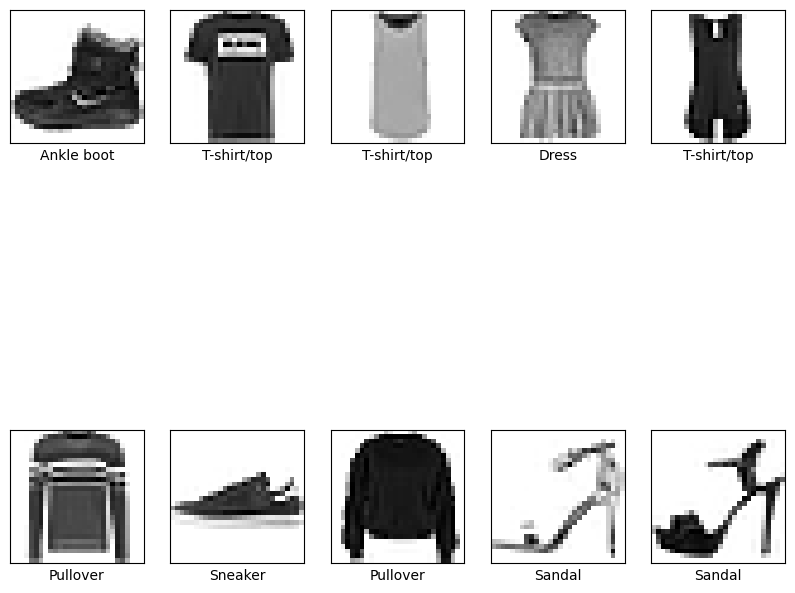

In [26]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]
# TODO: add your code here..
plt.figure(figsize=(10,10))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    
    # Replace numeric label with class name
    plt.xlabel(class_names[y_train[i]])

plt.show()

### More Notebook code

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7104 - loss: 0.9221 - val_accuracy: 0.7857 - val_loss: 0.6251
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8121 - loss: 0.5660 - val_accuracy: 0.8190 - val_loss: 0.5282
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8282 - loss: 0.5038 - val_accuracy: 0.8326 - val_loss: 0.4871
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8365 - loss: 0.4726 - val_accuracy: 0.8350 - val_loss: 0.4731
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8432 - loss: 0.4514 - val_accuracy: 0.8339 - val_loss: 0.4738
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8508 - loss: 0.4343 - val_accuracy: 0.8373 - val_loss: 0.4571
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8537 - loss: 0.4199 - val_accuracy: 0.8528 - val_loss: 0.4194
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8576 - loss: 0.4098 - val_accuracy: 0.

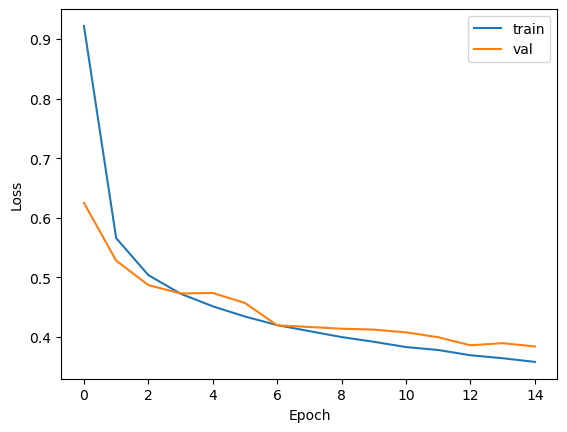

In [27]:

model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])


model.compile(
    #optimizer='adam',  # TODO: try 'adam'
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

log_dir = "logs/mlp_" + strftime("%Y%m%d-%H%M%S")
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    TensorBoard(log_dir=log_dir)
]

history = model.fit(
    X_train, y_train,
    epochs=15,
    validation_split=0.2,
    #validation_data=(X_valid, y_valid),
    callbacks=callbacks,
    batch_size=64
)

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


### 8: Tasks and questions on the MLP

In [18]:
# Start tensorboard as a background task - break it by stopping the kernel
!tensorboard --logdir logs

^C


### Open browser to view tensorboard: http://localhost:6006/

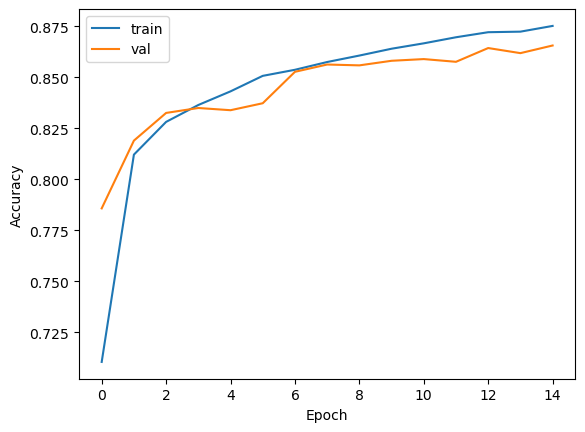

In [29]:
# Accuracy plots
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#### TensorBoard Analysis

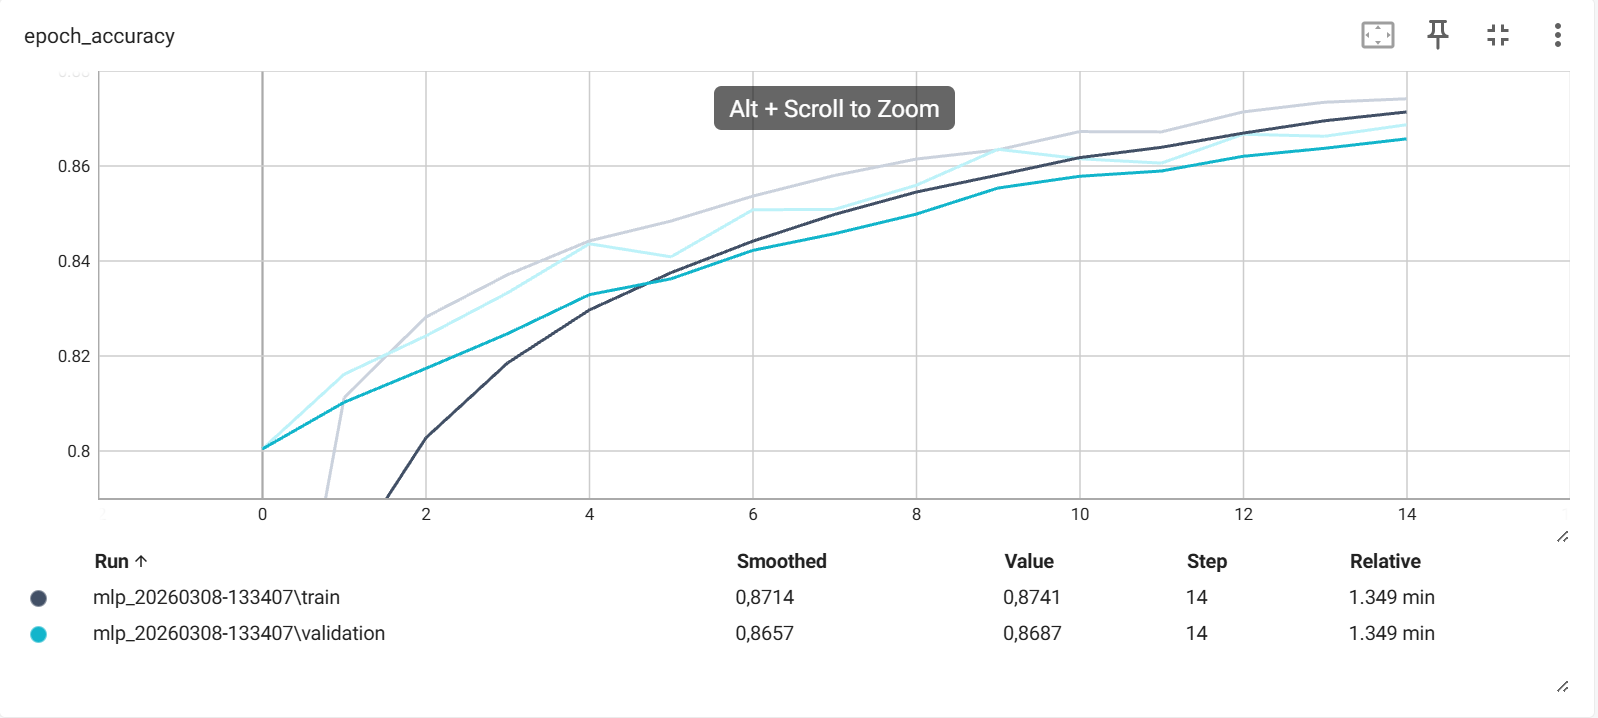

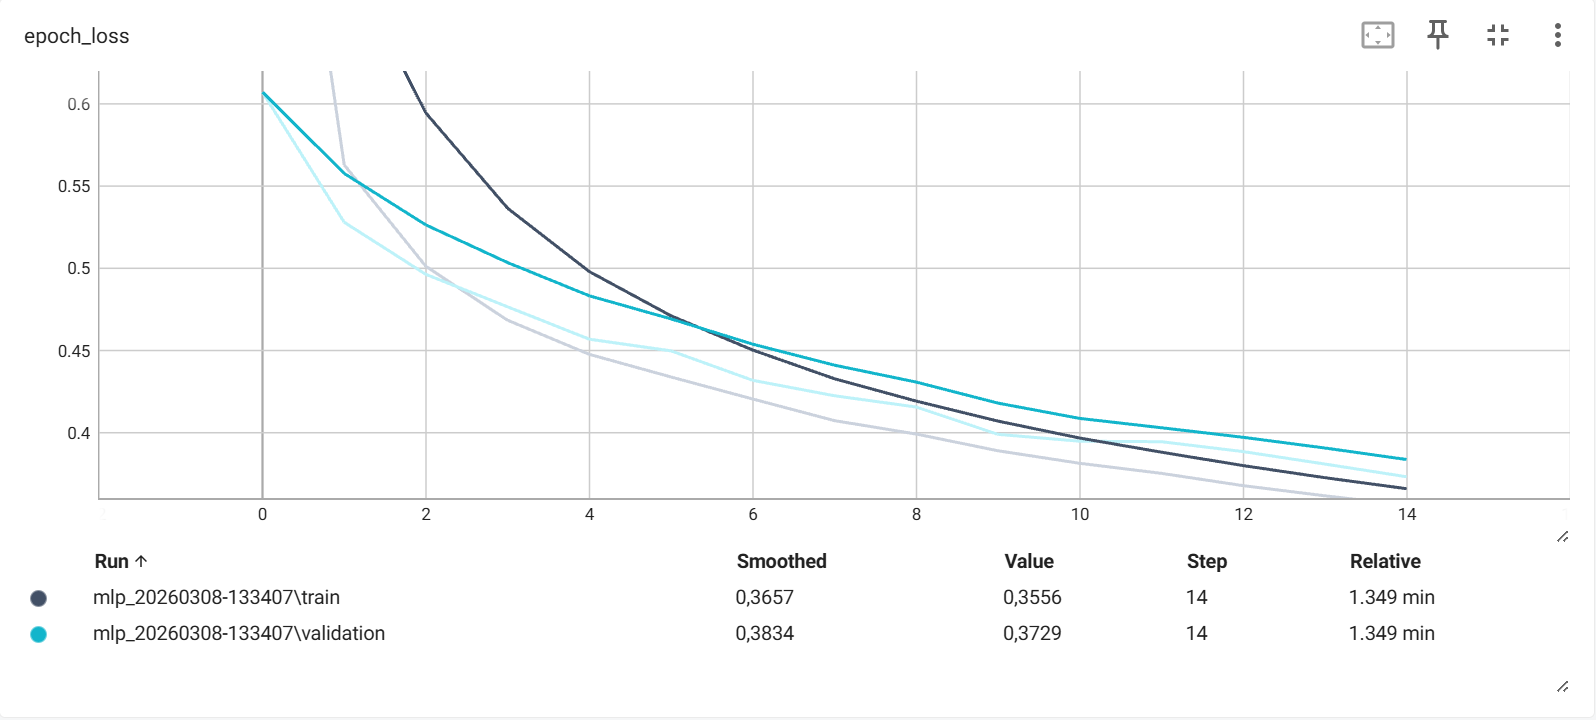

As seen in the screenshots above the the accuracy increases for each epoch wheras the loss decreases for each epoch - as expected.

### Additional Tasks on dataset
For each subtask a new model is created where the given parameter is tweaked - at the end each model is plotted together to show the effect of each parameter.

In [30]:
# Aditional tasks to optimize acc
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout
import tensorflow as tf
import matplotlib.pyplot as plt

### T8.c

In [31]:
# Callbacks
log_dir = "logs/mlp_" + strftime("%Y%m%d-%H%M%S")

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    TensorBoard(log_dir=log_dir)
]

# T8.c - More training Epochs
model_t8c = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model_t8c.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_t8c = model_t8c.fit(
    X_train, y_train,
    epochs=30,
    validation_split=0.2,
    callbacks=callbacks,
    batch_size=64
)

Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8154 - loss: 0.5173 - val_accuracy: 0.8457 - val_loss: 0.4197
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8624 - loss: 0.3755 - val_accuracy: 0.8655 - val_loss: 0.3635
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8779 - loss: 0.3325 - val_accuracy: 0.8783 - val_loss: 0.3349
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8855 - loss: 0.3057 - val_accuracy: 0.8760 - val_loss: 0.3438
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8936 - loss: 0.2865 - val_accuracy: 0.8788 - val_loss: 0.3240
Epoch 6/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8986 - loss: 0.2737 - val_accuracy: 0.8814 - val_loss: 0.3295
Epoch 7/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9021 - loss: 0.2594 - val_accuracy: 0.8848 - val_loss: 0.3150
Epoch 8/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9060 - loss: 0.2483 - val_accuracy: 0

### T8.d

In [32]:
# Callbacks
log_dir = "logs/mlp_" + strftime("%Y%m%d-%H%M%S")

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    TensorBoard(log_dir=log_dir)
]
# T8.d - Add a third hidden layer
model_t8d = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model_t8d.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_t8d = model_t8d.fit(
    X_train, y_train,
    epochs=15,
    validation_split=0.2,
    callbacks=callbacks,
    batch_size=64
)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8176 - loss: 0.5121 - val_accuracy: 0.8476 - val_loss: 0.4179
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8626 - loss: 0.3718 - val_accuracy: 0.8674 - val_loss: 0.3659
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8760 - loss: 0.3384 - val_accuracy: 0.8651 - val_loss: 0.3647
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8840 - loss: 0.3120 - val_accuracy: 0.8738 - val_loss: 0.3426
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8883 - loss: 0.2968 - val_accuracy: 0.8816 - val_loss: 0.3214
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8951 - loss: 0.2781 - val_accuracy: 0.8822 - val_loss: 0.3301
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9016 - loss: 0.2664 - val_accuracy: 0.8842 - val_loss: 0.3240
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9033 - loss: 0.2555 - val_accuracy

### T8.e

In [ ]:
# Callbacks
log_dir = "logs/mlp_" + strftime("%Y%m%d-%H%M%S")

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    TensorBoard(log_dir=log_dir)
]
# T8.e - Different number of neurons

model_t8e = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])

model_t8e.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_t8e = model_t8e.fit(
    X_train, y_train,
    epochs=15,
    validation_split=0.2,
    callbacks=callbacks,
    batch_size=64
)

### T8.f

In [ ]:
# Callbacks
log_dir = "logs/mlp_" + strftime("%Y%m%d-%H%M%S")

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    TensorBoard(log_dir=log_dir)
]
# T8.f - Trying other activation functions
model_t8f = Sequential([
    Input(shape=(28, 28)),
    Flatten(),

    # tanh (hyperbolic tangent)
    # - Outputs values between -1 and 1
    # - Centered around zero, which can sometimes help training
    Dense(256, activation='tanh'),

    # ELU (Exponential Linear Unit)
    # - Similar to ReLU but allows small negative outputs
    # - Often improves gradient flow and training stability
    Dense(128, activation='elu'),

    # softmax
    # - Converts outputs into probabilities
    # - Ensures all outputs sum to 1
    Dense(10, activation='softmax')
])

model_t8f.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_t8f = model_t8f.fit(
    X_train, y_train,
    epochs=15,
    validation_split=0.2,
    callbacks=callbacks,
    batch_size=64
)

Epoch 1/15
745/750 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7722 - loss: 0.6386

### T8.g

In [ ]:
# Callbacks
log_dir = "logs/mlp_" + strftime("%Y%m%d-%H%M%S")

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    TensorBoard(log_dir=log_dir)
]
# T8.g - Adding drop-out layers
model_t8g = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

model_t8g.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_t8g = model_t8g.fit(
    X_train, y_train,
    epochs=15,
    validation_split=0.2,
    callbacks=callbacks,
    batch_size=64
)

In [ ]:
# Compare validation accuracy of all experiments

plt.plot(history_t8c.history['val_accuracy'], label='T8.c more epochs')
plt.plot(history_t8d.history['val_accuracy'], label='T8.d third layer')
plt.plot(history_t8e.history['val_accuracy'], label='T8.e more neurons')
plt.plot(history_t8f.history['val_accuracy'], label='T8.f activations')
plt.plot(history_t8g.history['val_accuracy'], label='T8.g dropout')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Comparison')
plt.legend()
plt.show()

### T8.h

In [ ]:
# Callbacks
log_dir = "logs/mlp_" + strftime("%Y%m%d-%H%M%S")

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    TensorBoard(log_dir=log_dir)
]
# T8.h - Creating new model and testing on data

# Best MLP model based on the tested parameters

model_best = Sequential([
    Input(shape=(28, 28)),
    Flatten(),

    # Hidden layer 1
    Dense(512, activation='relu'),
    Dropout(0.3),

    # Hidden layer 2
    Dense(256, activation='relu'),
    Dropout(0.3),

    # Hidden layer 3
    Dense(128, activation='relu'),

    # Output layer for 10 classes
    Dense(10, activation='softmax')
])

model_best.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_best = model_best.fit(
    X_train, y_train,
    epochs=20,
    validation_split=0.2,
    callbacks=callbacks,
    batch_size=64
)

test_loss, test_acc = model_best.evaluate(X_test, y_test)
print("Best model test loss:", test_loss)
print("Best model test accuracy:", test_acc)

In [ ]:
model_best.save("fashion_mnist_best_model.keras")

reloaded_model = tf.keras.models.load_model("fashion_mnist_best_model.keras")

reload_loss, reload_acc = reloaded_model.evaluate(X_test, y_test)
print("Reloaded model test loss:", reload_loss)
print("Reloaded model test accuracy:", reload_acc)

### Questions on Model Training

Q8a: By temporarily dropping out some of the neurons accuracy will be boosted and the tendency for overfitting is also decreased.

Q8b: Overfitting is when the model learns the data too well and thereby includes all the noise in the data. Underfitting is when it is too simple.

Q8c: Patience influences the amount of epochs the model will continue training if no change in validation loss has occured.

Q8d: If eta is too small the SGD updates the weights too slow and the model will converge to slowly.

Q8e: Adam is easier to use as it is an adaptive learning rate algorithm, where SGD uses a constant learning rate. Adam will therefore also converge faster.

Q8e: The first layer receives 28 x 28 = 784 inputs and has 256 neurons => (784 x 256) + 256 = 200.960

Q8f: Adam performed better as it converged faster

Q8g: Adding layers increases accuracy but is also computationally heavier

Q8h: Using earlystopping forces the model to break out of training when the validation loss doesnt improve - this prevents the model of learning specific patterns that might cause it to overfit.

Q8i: Adding more neurons had the biggest immediate impact.